Lab 1

Zadanie nr 1 wariant 14

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

Osiągnięto wymagany błąd (MSE < 0.01) w epoce 16!


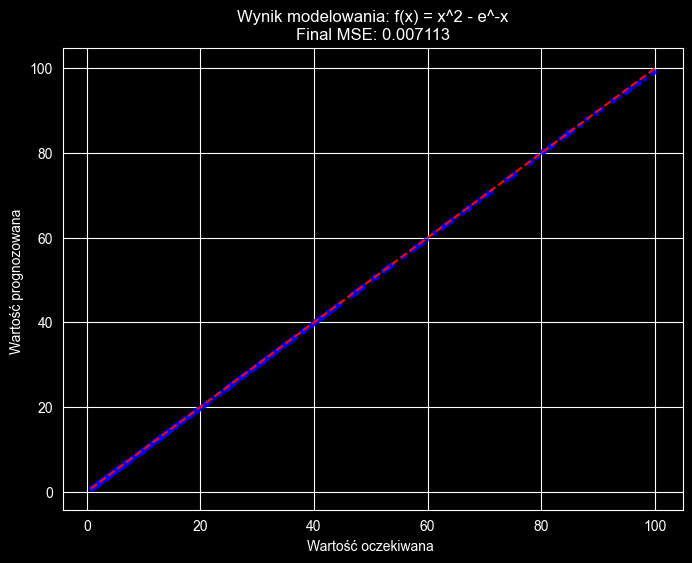

In [52]:

# 1. Generowanie danych
X_np = np.linspace(1, 10, 2000).reshape(-1, 1).astype(np.float32)
y_np = (X_np**2 - np.exp(-X_np)).astype(np.float32)

# Podział na zbiór treningowy i testowy
indices = np.random.permutation(len(X_np))
train_idx, test_idx = indices[:1600], indices[1600:]

X_train_tensor = torch.from_numpy(X_np[train_idx])
y_train_tensor = torch.from_numpy(y_np[train_idx]).squeeze()
X_test_tensor = torch.from_numpy(X_np[test_idx])
y_test_tensor = torch.from_numpy(y_np[test_idx]).squeeze()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 2. RegressionNN
# 0 warstw ukryrtych
# class RegressionNN(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
#         self.fc1 = nn.Linear(input_dim, 1)
#
#     def forward(self, x):
#         return self.fc1(x).squeeze()

# 1 warstwa ukryta
# class RegressionNN(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
#         self.fc1 = nn.Linear(input_dim, 64)
#         self.fc2 = nn.Linear(64, 1)
#
#     def forward(self, x):
#         x = torch.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x.squeeze()

# 2 warstwy ukryte
class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x.squeeze()

# 3. Inicjalizacja modelu i parametrów
model = RegressionNN(X_train_tensor.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. Pętla uczenia
epochs = 200
for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # Sprawdzanie warunku Error < 0.01
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_tensor)
        test_loss = criterion(test_pred, y_test_tensor)

    if test_loss.item() < 0.01:
        print(f"Osiągnięto wymagany błąd (MSE < 0.01) w epoce {epoch+1}!")
        break

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Test Loss: {test_loss.item():.6f}")

# 5. Wykres punktowy (Oś X: oczekiwana, Oś Y: prognozowana)
model.eval()
with torch.no_grad():
    y_final_pred = model(X_test_tensor).numpy()
    y_final_true = y_test_tensor.numpy()

plt.figure(figsize=(8, 6))
plt.scatter(y_final_true, y_final_pred, alpha=0.5, color='blue', s=10)
plt.plot([y_final_true.min(), y_final_true.max()],
         [y_final_true.min(), y_final_true.max()],
         color='red', linestyle='--')
plt.xlabel("Wartość oczekiwana ")
plt.ylabel("Wartość prognozowana ")
plt.title(f"Wynik modelowania: f(x) = x^2 - e^-x\nFinal MSE: {test_loss.item():.6f}")
plt.grid(True)
plt.show()

Zadanie nr 2 wariant 14

Epoch 20/200, Test Loss: 337.663971
Epoch 40/200, Test Loss: 338.468903
Epoch 60/200, Test Loss: 337.612823
Epoch 80/200, Test Loss: 334.551239
Epoch 100/200, Test Loss: 336.972748
Epoch 120/200, Test Loss: 337.284302
Epoch 140/200, Test Loss: 340.777740
Epoch 160/200, Test Loss: 343.590851
Epoch 180/200, Test Loss: 345.671844
Epoch 200/200, Test Loss: 346.553802


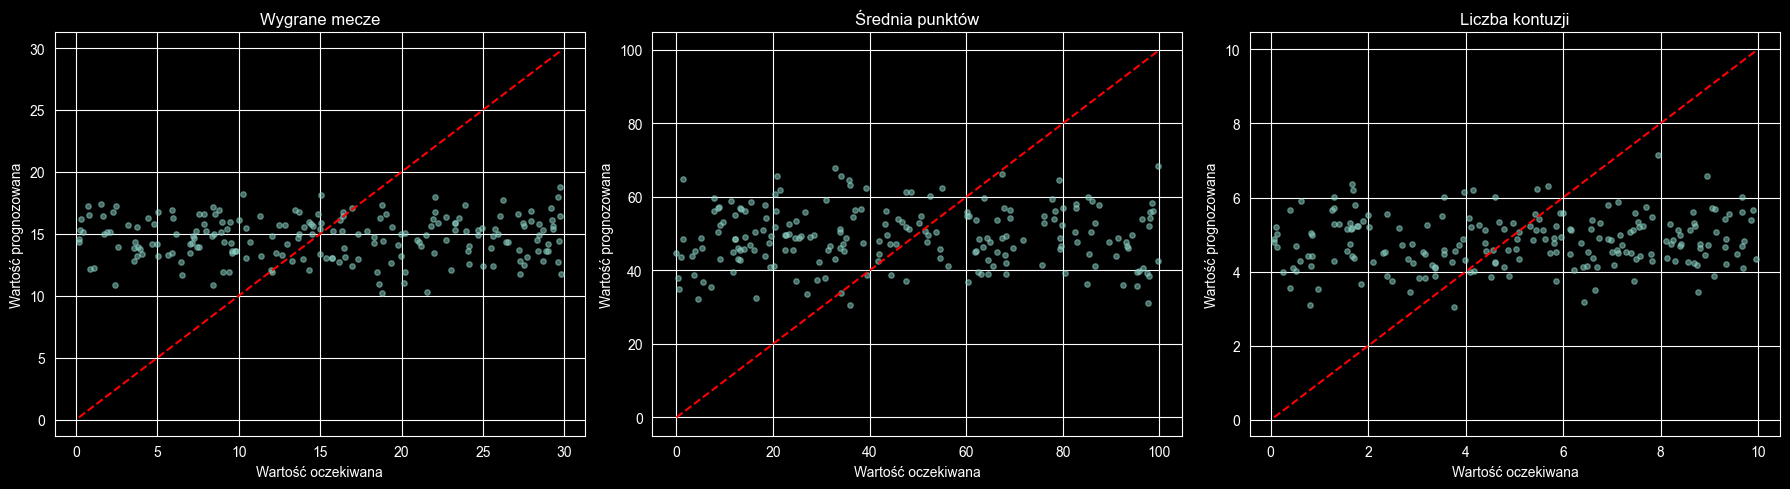

In [53]:

# 1. Generowanie danych
np.random.seed(42)
X_np = (np.random.rand(1000, 4) * [10, 10, 15, 5]).astype(np.float32)
y_np = (np.random.rand(1000, 3) * [30, 100, 10]).astype(np.float32)

#dane, które mają sens (tylko do testu)
X_np = (np.random.rand(1000, 4) * [10, 10, 15, 5]).astype(np.float32)
y_np = np.zeros((1000, 3), dtype=np.float32)
y_np[:, 0] = X_np[:, 0] * 2 + X_np[:, 1] * 0.5
y_np[:, 1] = X_np[:, 2] * 5
y_np[:, 2] = X_np[:, 0] * 0.8

# Podział na zbiór treningowy i testowy (80/20)
indices = np.random.permutation(len(X_np))
train_idx, test_idx = indices[:800], indices[800:]

X_train_tensor = torch.from_numpy(X_np[train_idx])
y_train_tensor = torch.from_numpy(y_np[train_idx])
X_test_tensor = torch.from_numpy(X_np[test_idx])
y_test_tensor = torch.from_numpy(y_np[test_idx])

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


class RegressionNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)

        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)

        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = self.bn1(self.fc1(x))
        x = torch.relu(x)

        x = self.bn2(self.fc2(x))
        x = torch.relu(x)

        x = self.fc3(x)
        return x

# 3. Inicjalizacja modelu
model = RegressionNN(input_dim=4, output_dim=3)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. Pętla uczenia
epochs = 200
for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_tensor)
        test_loss = criterion(test_pred, y_test_tensor)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Test Loss: {test_loss.item():.6f}")


# 5. Wykresy wyników
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()
    targets = y_test_tensor.numpy()

# Tworzymy wykresy dla każdej z 3 zmiennych wyjściowych
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Wygrane mecze', 'Średnia punktów', 'Liczba kontuzji']

for i in range(3):
    axs[i].scatter(targets[:, i], predictions[:, i], alpha=0.5, s=15)
    axs[i].plot([targets[:, i].min(), targets[:, i].max()],
                [targets[:, i].min(), targets[:, i].max()], 'r--')
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Wartość oczekiwana")
    axs[i].set_ylabel("Wartość prognozowana")

plt.tight_layout()
plt.show()